<a href="https://colab.research.google.com/github/Stephen-G-Peterson/MachineLearning/blob/main/HW1_Stephen_Peterson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Collaboration Disclaimer:
Gemini 3.6 Flash was used on this assignment to help with the syntax for the figure plotting in parts 4, 6, and 7.

I have reviewed the code in these parts before submission

In [12]:
#imports given
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns # import the seaborn library
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [2]:
iot_data = pd.read_csv("/content/iot_dataset.csv") #read data from spreadsheet
iot_data.head()#print first few rows

,x1,x2,x3,x4,x5,x6,y
0,34.40,-16.400,2600.0,26.7,2.92,1950.0,0.0
1,30.40,1.140,1770.0,30.2,1.91,1030.0,1.0
2,19.90,-4.050,2430.0,29.9,2.25,1670.0,0.0
3,30.70,0.231,2330.0,25.6,2.29,1580.0,1.0
4,3.73,12.600,372.0,48.5,0.28,1040.0,0.0


In [3]:
#rename columns
iot_data = iot_data.rename(columns={'x1': 'temp', 'x2': 'humidity', 'x3': 'light', 'x4': 'noise', 'x5': 'motion', 'x6': 'device ID', 'y': 'class'})
iot_data.head()

,temp,humidity,light,noise,motion,device ID,class
0,34.40,-16.400,2600.0,26.7,2.92,1950.0,0.0
1,30.40,1.140,1770.0,30.2,1.91,1030.0,1.0
2,19.90,-4.050,2430.0,29.9,2.25,1670.0,0.0
3,30.70,0.231,2330.0,25.6,2.29,1580.0,1.0
4,3.73,12.600,372.0,48.5,0.28,1040.0,0.0


In [4]:
print(iot_data['class'].value_counts())

class
0.0    1000
1.0     999
Name: count, dtype: int64


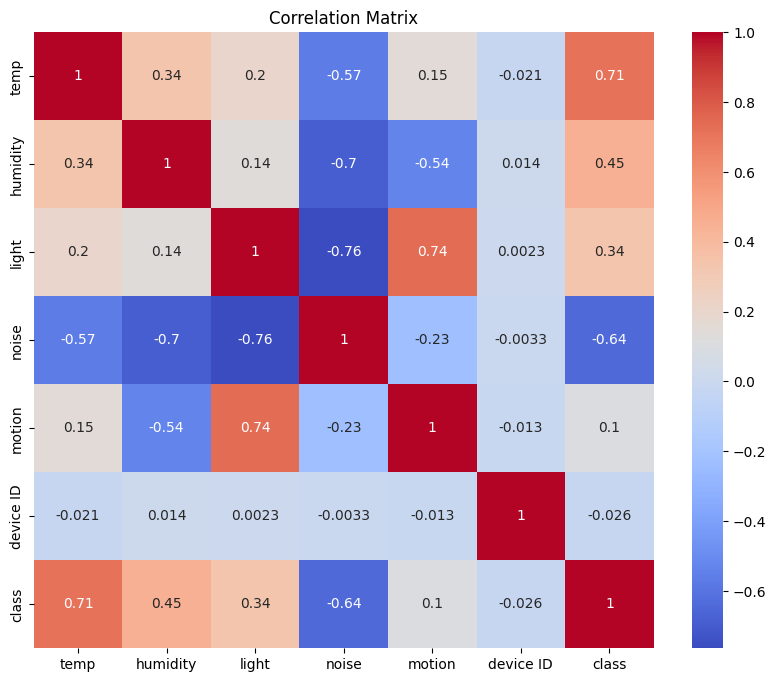

In [5]:
corr = iot_data.corr(); #generate correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2g")#gemini assisted
plt.title("Correlation Matrix")
plt.show()

## Explination:

Strong positive(both features foolow each other closely):

    class and temp
    motion and light


Strong negative(both features move in oppsoite derections):

    noise and class
    noise and humidity
    noise and light

Moderate(both features have a smaller but still sginifcant correlation)

    noise and temp
    motion and humidity

No correlation(these two feature do not have any predictable patterns between each other)
    
    device id and everything
    -this makes sense, since the id of an item usually has no relationship to the rest of its enviornment


In [6]:
X = iot_data.drop(columns=['class'])
y = iot_data['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)#define the scale based on the dataset minus the class column

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

scaled_df['class'] = y.values

scaled_df.head()

,temp,humidity,light,noise,motion,device ID,class
0,1.031508,-0.928271,1.403794,-0.690312,2.014214,1.576464,0.0
1,0.735717,-0.402084,0.799490,-0.499532,1.085802,-1.618401,1.0
2,-0.040735,-0.557780,1.280021,-0.515885,1.398337,0.604114,0.0
3,0.757901,-0.429353,1.207214,-0.750271,1.435106,0.291573,1.0
4,-1.236470,-0.058292,-0.218362,0.497971,-0.412526,-1.583674,0.0


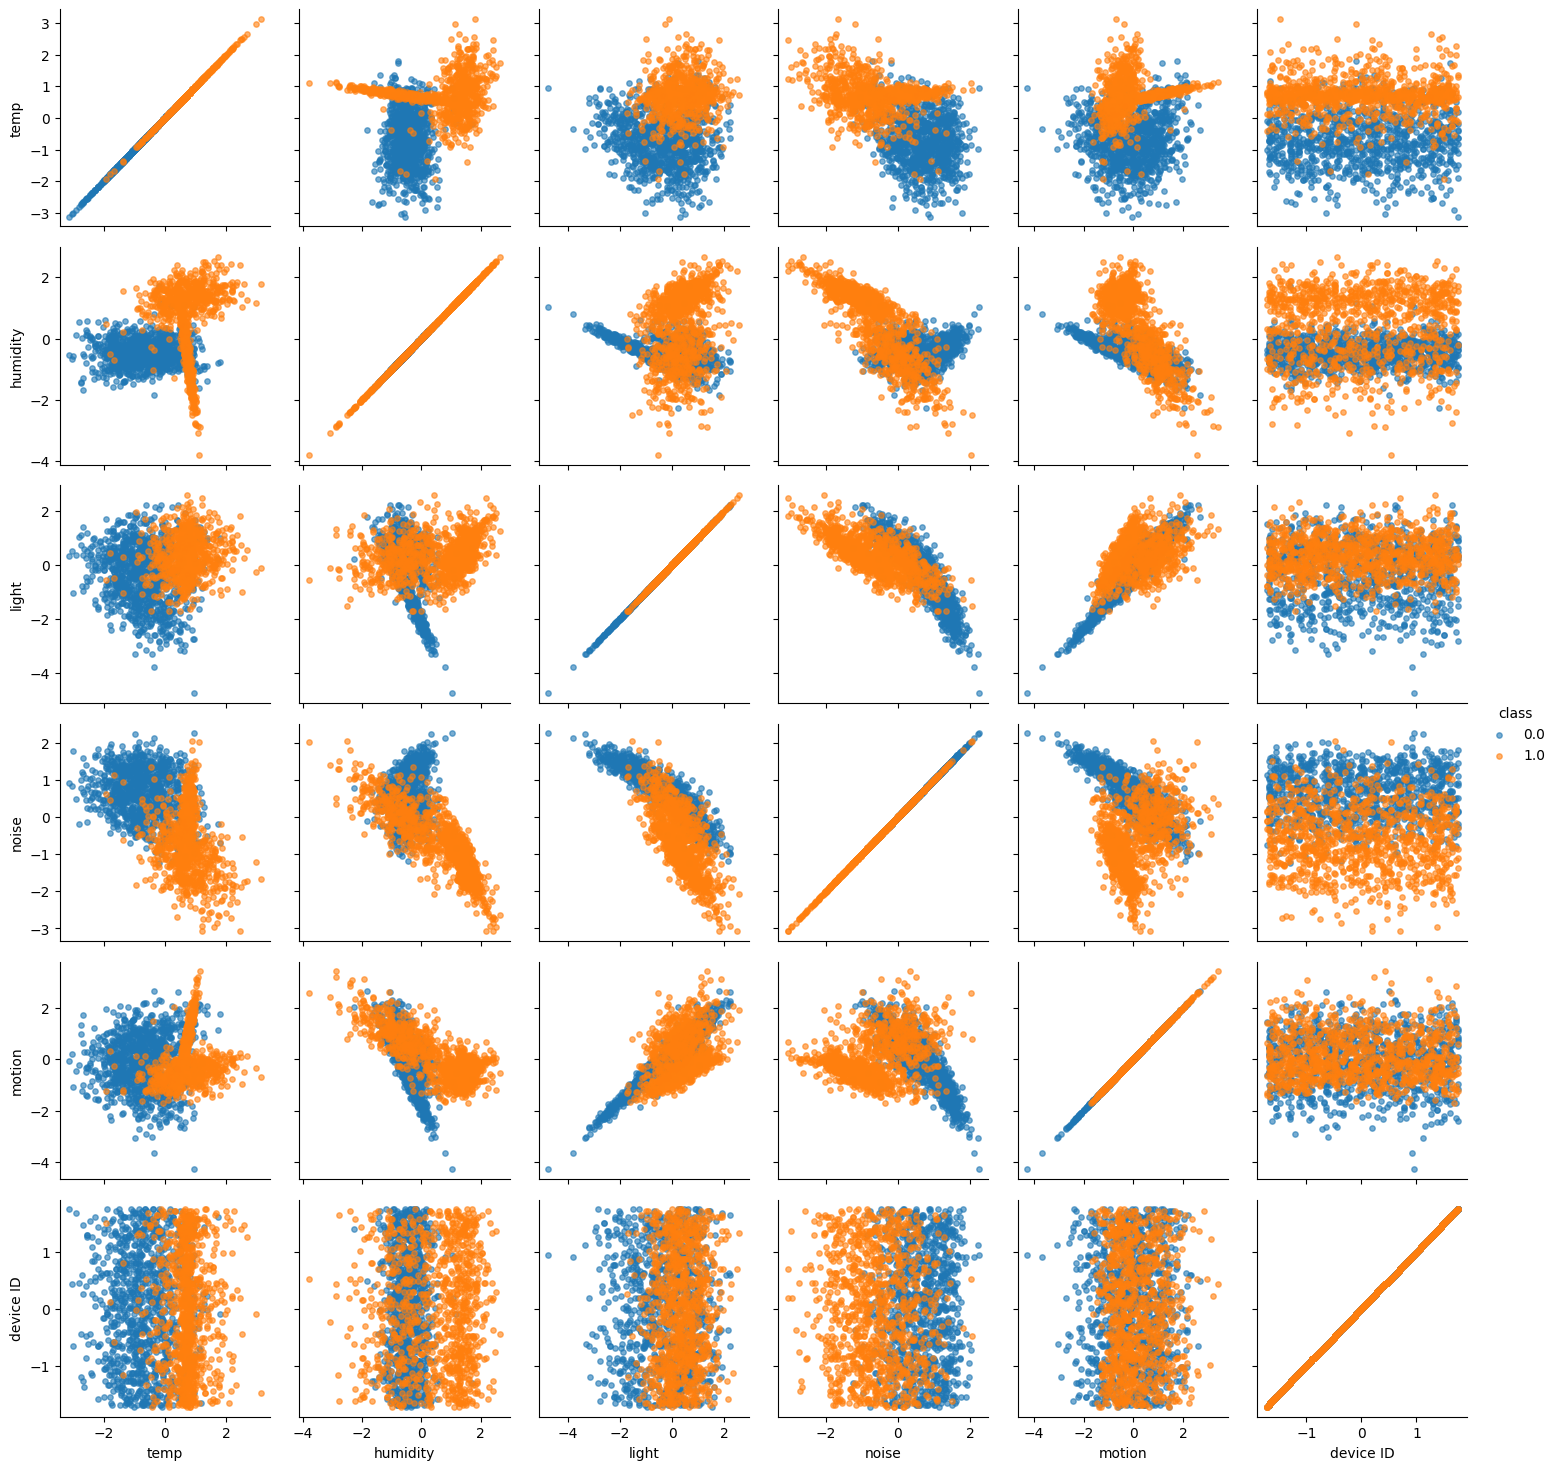

In [7]:
g = sns.PairGrid(scaled_df, hue='class', palette={0: '#1f77b4', 1: '#ff7f0e'})#pararms generated using gemini

g.map(plt.scatter, alpha=0.6, s=15)

g.add_legend()

plt.show()

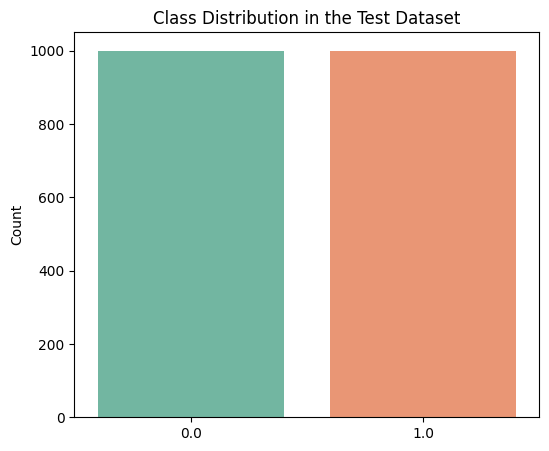

In [11]:
plt.figure(figsize=(6, 5))

sns.countplot(x=scaled_df['class'], hue=scaled_df['class'], palette="Set2", legend=False)

plt.title("Class Distribution in the Test Dataset")
plt.ylabel("Count")
plt.xlabel("")

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_df.drop(columns=['class']),
    scaled_df['class'],
    test_size=0.2,#make 20% of the dataset be the test set
    stratify=scaled_df['class']
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

         0.0       0.91      0.92      0.92       200
         1.0       0.92      0.91      0.91       200

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.91       400
weighted avg       0.92      0.92      0.91       400



Precision: For the instances that were predicted as class 0, 91% were actually class 0

for calss 1, 92% were correct

Recall:
for class 0, 92% of actual class 0 instances were correctly identified

for class 1, 91% were correclty identified.

F1:

the mean betweeen both precision and recall - 92% and 91% for class 0 and 1 respectivly

Support:
  the ammount of occurences for the specified instance. since the testing set was defined as 20% of the dataset, the support will be 200 for all classes.

Accuracy: the final score on how accurate the model is - 92%

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print(classification_report(y_test, y_pred_knn, digits=2))

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       200
         1.0       0.95      0.95      0.95       200

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



Precision: For the instances that were predicted as class 0, 95% were actually class 0

for calss 1, 95% were correct

Recall:
for class 0, 95% of actual class 0 instances were correctly identified

for class 1, 95% were correclty identified.

F1:

the mean betweeen both precision and recall - 95% for class 0 and 1

Support:
  the ammount of occurences for the specified instance. since the testing set was defined as 20% of the dataset, the support will be 200 for all classes.

Accuracy: the final score on how accurate the model is - 95%

In [14]:
svm_model = SVC()
svm_model.fit(X_train, y_train)#reuse the same training set from the previous cell

y_pred_svm = svm_model.predict(X_test)

print(classification_report(y_test, y_pred_svm, digits=2))

              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       200
         1.0       0.97      0.97      0.97       200

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



Precision: For the instances that were predicted as class 0, 97% were actually class 0

for calss 1, 97% were correct

Recall:
for class 0, 96% of actual class 0 instances were correctly identified

for class 1, 97% were correclty identified.

F1:

the mean betweeen both precision and recall - 97% for both class 0 and 1

Support:
  the ammount of occurences for the specified instance. since the testing set was defined as 20% of the dataset, the support will be 200 for all classes.

Accuracy: the final score on how accurate the model is - 97%

#overall
the logistic regression had a high accuracy of .92 for its predictions. This is a moderatly good score that could be passable in some situations

the knn model had a higher score of .95 which would make it preferable over the logistic regression

SVM had the best score at .97 making it the preferred modle to use for this dataset.